# Feature Engineering

Machine Learning models cannot read English words. They need numbers. Here, we use TF-IDF to convert cleaned text into a matrix of numerical features.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import show_top_ngrams_by_class, add_basic_meta_features, plot_dimensionality_reduction, save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks


/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/src/utils/helpers.py:290: SyntaxWarning: invalid escape sequence '\?'
  df['question_count'] = s.str.count('\?')


/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


load cleaned text

In [3]:
processed_train = pd.read_csv(r'data/processed/processed_train.csv', dtype=str, quoting=0)
processed_train.head()

,review_target,review_title,review_content,char_count,word_count,review_cleaned
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...


In [4]:
processed_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_target   100 non-null    str  
 1   review_title    100 non-null    str  
 2   review_content  100 non-null    str  
 3   char_count      100 non-null    str  
 4   word_count      100 non-null    str  
 5   review_cleaned  100 non-null    str  
dtypes: str(6)
memory usage: 4.8 KB


top unigrams, bigrams, and trigrams per class

In [5]:
feat_eng_train = processed_train.copy()


Top unigrams for class 1 and 2 of cleaned review

--- Top unigrams for class 1 ---
[('book', np.int64(27)), ('like', np.int64(17)), ('product', np.int64(13)), ('work', np.int64(13)), ('good', np.int64(13)), ('make', np.int64(12)), ('bought', np.int64(12)), ('buy', np.int64(11)), ('read', np.int64(10)), ('battery', np.int64(10)), ('look', np.int64(9)), ('better', np.int64(9)), ('year', np.int64(9)), ('day', np.int64(8)), ('know', np.int64(8))]



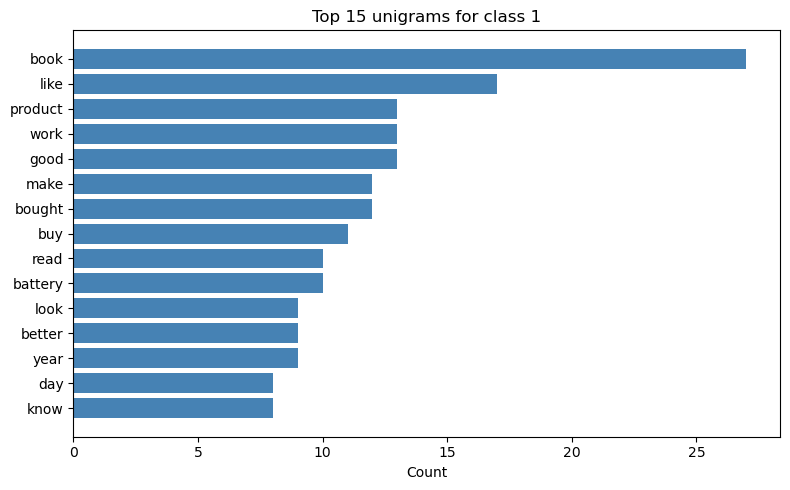

--- Top unigrams for class 2 ---
[('book', np.int64(21)), ('use', np.int64(18)), ('good', np.int64(18)), ('great', np.int64(17)), ('time', np.int64(14)), ('like', np.int64(14)), ('read', np.int64(13)), ('product', np.int64(11)), ('easy', np.int64(11)), ('know', np.int64(10)), ('day', np.int64(8)), ('love', np.int64(8)), ('reading', np.int64(8)), ('used', np.int64(8)), ('movie', np.int64(7))]



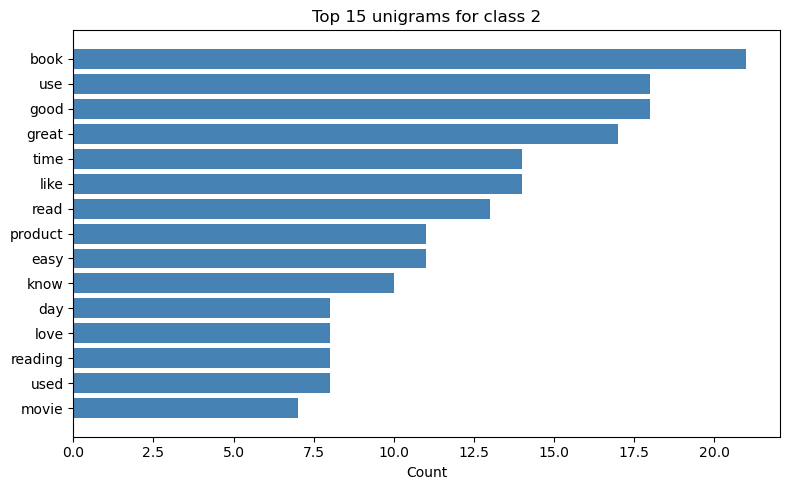

{'1': {(1, 1): [('book', np.int64(27)),
   ('like', np.int64(17)),
   ('product', np.int64(13)),
   ('work', np.int64(13)),
   ('good', np.int64(13)),
   ('make', np.int64(12)),
   ('bought', np.int64(12)),
   ('buy', np.int64(11)),
   ('read', np.int64(10)),
   ('battery', np.int64(10)),
   ('look', np.int64(9)),
   ('better', np.int64(9)),
   ('year', np.int64(9)),
   ('day', np.int64(8)),
   ('know', np.int64(8))]},
 '2': {(1, 1): [('book', np.int64(21)),
   ('use', np.int64(18)),
   ('good', np.int64(18)),
   ('great', np.int64(17)),
   ('time', np.int64(14)),
   ('like', np.int64(14)),
   ('read', np.int64(13)),
   ('product', np.int64(11)),
   ('easy', np.int64(11)),
   ('know', np.int64(10)),
   ('day', np.int64(8)),
   ('love', np.int64(8)),
   ('reading', np.int64(8)),
   ('used', np.int64(8)),
   ('movie', np.int64(7))]}}

In [6]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(1, 1), top_k=15)


Top bigrams for class 1 and 2 of cleaned review

--- Top bigrams for class 1 ---
[('ice cream', np.int64(4)), ('waffle iron', np.int64(3)), ('high school', np.int64(3)), ('year old', np.int64(3)), ('written character', np.int64(2)), ('waste money', np.int64(2)), ('end millennium', np.int64(2)), ('poorly written', np.int64(2)), ('holder card', np.int64(2)), ('new music', np.int64(2)), ('networker gmail', np.int64(2)), ('issue printer', np.int64(2))]



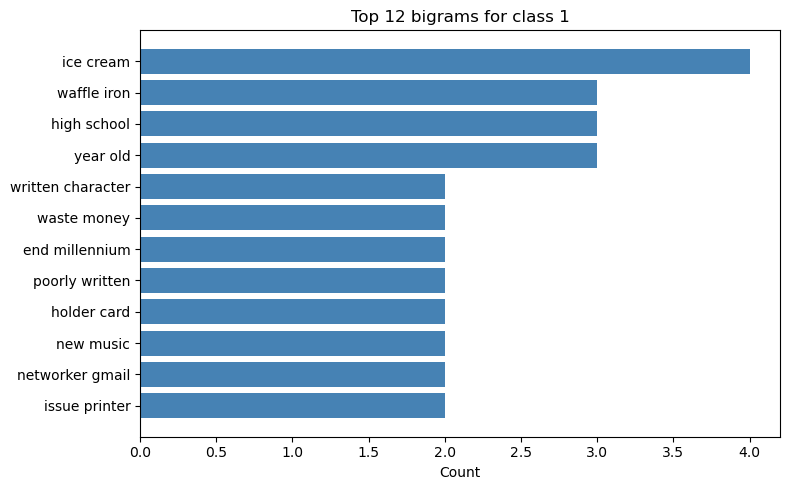

--- Top bigrams for class 2 ---
[('easy use', np.int64(4)), ('looking forward', np.int64(3)), ('long time', np.int64(3)), ('highly recommend', np.int64(3)), ('work great', np.int64(2)), ('small inconvenience', np.int64(2)), ('taping knife', np.int64(2)), ('good book', np.int64(2)), ('word love', np.int64(2)), ('know hitler', np.int64(2)), ('people know', np.int64(2)), ('big bottle', np.int64(2))]



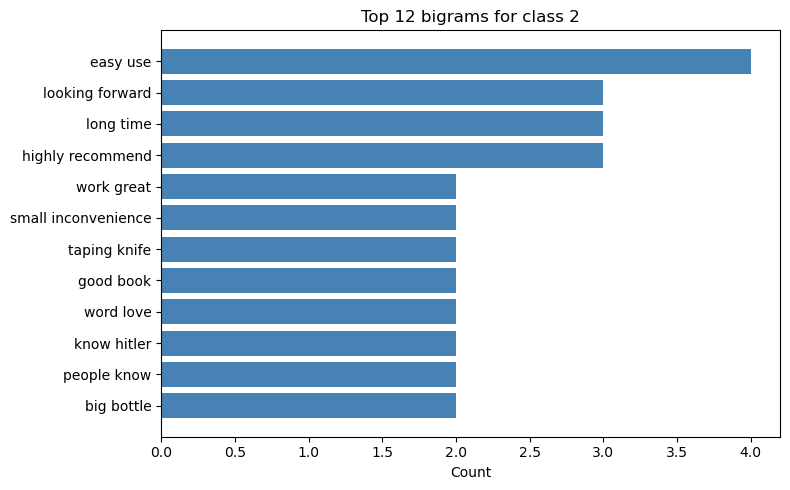

{'1': {(2, 2): [('ice cream', np.int64(4)),
   ('waffle iron', np.int64(3)),
   ('high school', np.int64(3)),
   ('year old', np.int64(3)),
   ('written character', np.int64(2)),
   ('waste money', np.int64(2)),
   ('end millennium', np.int64(2)),
   ('poorly written', np.int64(2)),
   ('holder card', np.int64(2)),
   ('new music', np.int64(2)),
   ('networker gmail', np.int64(2)),
   ('issue printer', np.int64(2))]},
 '2': {(2, 2): [('easy use', np.int64(4)),
   ('looking forward', np.int64(3)),
   ('long time', np.int64(3)),
   ('highly recommend', np.int64(3)),
   ('work great', np.int64(2)),
   ('small inconvenience', np.int64(2)),
   ('taping knife', np.int64(2)),
   ('good book', np.int64(2)),
   ('word love', np.int64(2)),
   ('know hitler', np.int64(2)),
   ('people know', np.int64(2)),
   ('big bottle', np.int64(2))]}}

In [7]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(2, 2), top_k=12)


Top trigrams for class 1 and 2 of cleaned review

--- Top 3-3grams for class 1 ---
[('networker gmail com', np.int64(2)), ('poorly written character', np.int64(2)), ('fine using line', np.int64(1)), ('finish classic tmnt', np.int64(1)), ('flimsy dial cheapy', np.int64(1)), ('flimsy holder card', np.int64(1)), ('florence say care', np.int64(1)), ('fluffy book 20', np.int64(1)), ('forced leave review', np.int64(1)), ('forced volition kept', np.int64(1)), ('forever close getting', np.int64(1)), ('forth dance 15', np.int64(1))]



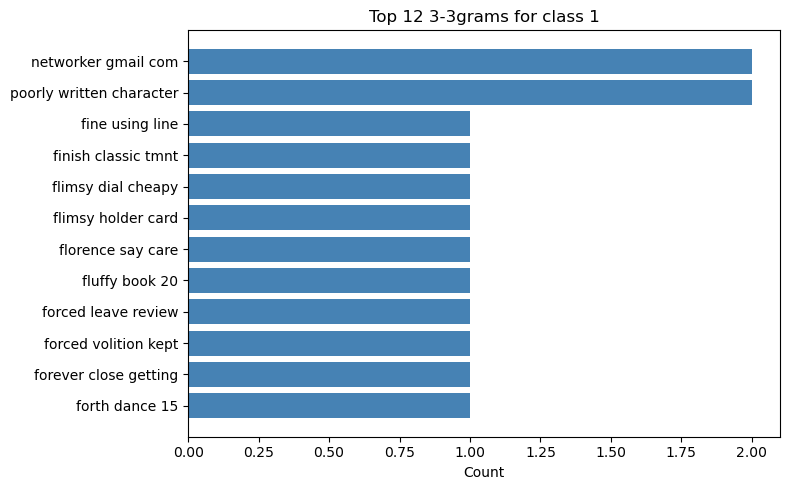

--- Top 3-3grams for class 2 ---
[('know hitler died', np.int64(2)), ('friend excellent product', np.int64(1)), ('friendship family religion', np.int64(1)), ('fun got gag', np.int64(1)), ('fun listening album', np.int64(1)), ('fun taking apple', np.int64(1)), ('function hardwood floor', np.int64(1)), ('funny moment fairy', np.int64(1)), ('gag gift ended', np.int64(1)), ('game lip met', np.int64(1)), ('gamut feeling present', np.int64(1)), ('friend amazed picture', np.int64(1))]



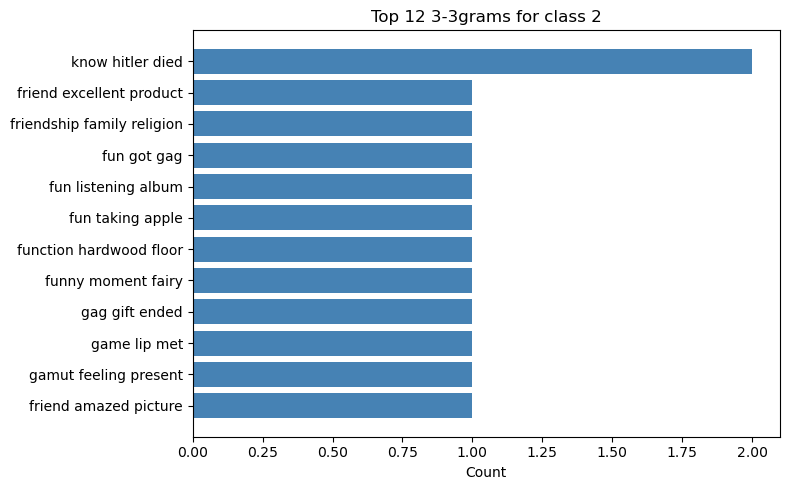

{'1': {(3, 3): [('networker gmail com', np.int64(2)),
   ('poorly written character', np.int64(2)),
   ('fine using line', np.int64(1)),
   ('finish classic tmnt', np.int64(1)),
   ('flimsy dial cheapy', np.int64(1)),
   ('flimsy holder card', np.int64(1)),
   ('florence say care', np.int64(1)),
   ('fluffy book 20', np.int64(1)),
   ('forced leave review', np.int64(1)),
   ('forced volition kept', np.int64(1)),
   ('forever close getting', np.int64(1)),
   ('forth dance 15', np.int64(1))]},
 '2': {(3, 3): [('know hitler died', np.int64(2)),
   ('friend excellent product', np.int64(1)),
   ('friendship family religion', np.int64(1)),
   ('fun got gag', np.int64(1)),
   ('fun listening album', np.int64(1)),
   ('fun taking apple', np.int64(1)),
   ('function hardwood floor', np.int64(1)),
   ('funny moment fairy', np.int64(1)),
   ('gag gift ended', np.int64(1)),
   ('game lip met', np.int64(1)),
   ('gamut feeling present', np.int64(1)),
   ('friend amazed picture', np.int64(1))]}}

In [8]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_cleaned', ngram_ranges=(3, 3), top_k=12)


Basic meta-features

In [32]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_content')
feat_eng_train

,review_target,review_title,review_content,char_count,word_count,review_cleaned,exclamation_count,question_count,punctuation_count,avg_word_length,uppercase_count,uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,0,0,14,4.435185,455,0.776451
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,0,0,12,5.488636,4,0.007018
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,0,0,5,4.375000,3,0.014019
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,0,0,2,4.705882,2,0.010363
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,1,0,9,4.236842,4,0.020202
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,2 stars for attempt,I bought this excitedly today anticipating the...,877,153,bought excitedly today anticipating effect wou...,0,0,21,4.738562,19,0.021665
96,2,An okay case,The case looks great and is light weight. The ...,554,108,case look great light weight concern mine savi...,0,0,20,4.138889,13,0.023466
97,2,The Boleyn Inheritance,I bought this as a Christmas present for two p...,208,39,bought christmas present two people already re...,1,0,9,4.358974,8,0.038462
98,2,Great Quality,"These lenses on these glasses are pretty dark,...",222,43,lens glass pretty dark great driving sun face ...,0,0,4,4.186047,2,0.009009


correlation with target

Convert target to numeric for correlation (fall back to category codes)

In [34]:
meta_cols= ['char_count', 'word_count', 'exclamation_count', 'question_count', 'punctuation_count', 'avg_word_length', 'uppercase_count', 'uppercase_ratio']
try:
    target_numeric = pd.to_numeric(feat_eng_train['review_target'], errors='coerce')
    if target_numeric.isna().sum() > len(target_numeric) * 0.5:
        target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    else:
        target_numeric = target_numeric.fillna(0)
except Exception:
    target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
corrs = {col: pd.Series(feat_eng_train[col]).corr(target_numeric) for col in meta_cols}
corr_series = pd.Series(corrs).sort_values(ascending=False)
print('Correlations between meta-features and target:')
print(corr_series)


Correlations between meta-features and target:
uppercase_ratio      0.111281
uppercase_count      0.084756
exclamation_count    0.052402
avg_word_length     -0.006790
punctuation_count   -0.018113
char_count          -0.116537
word_count          -0.122003
question_count      -0.190543
dtype: float64


`question_count (-0.190)`: `negative correlation`.    
This means that the `more questions` there are in the review, the more likely it is that the review will be `negative` (close to 0).

`word_count (-0.122)` & `char_count (-0.116)`: `negative correlation`.   
The `longer the review`, the more likely it is to be `negative`.

`uppercase_ratio (0.111)` & `uppercase_count (0.084)`: `positive correlation` (positive but weak).    
The `more capital letters`, the `more positive` the review tends to be.

`avg_word_length (-0.006)` & `punctuation_count (-0.018)`: These numbers are very close to zero.    
This means that these `features are almost useless` and do `not influence` whether the `review is positive or negative`.

Visualize separability using dimensionality reduction (PCA or TSNE)

In [35]:
tfidf_train = TfidfVectorizer(ngram_range=(1,2), max_features=20000, stop_words='english')
tfidf_train = tfidf_train.fit_transform(feat_eng_train['review_cleaned'].astype(str))
print('TF-IDF shape:', tfidf_train.shape)

TF-IDF shape: (100, 4887)


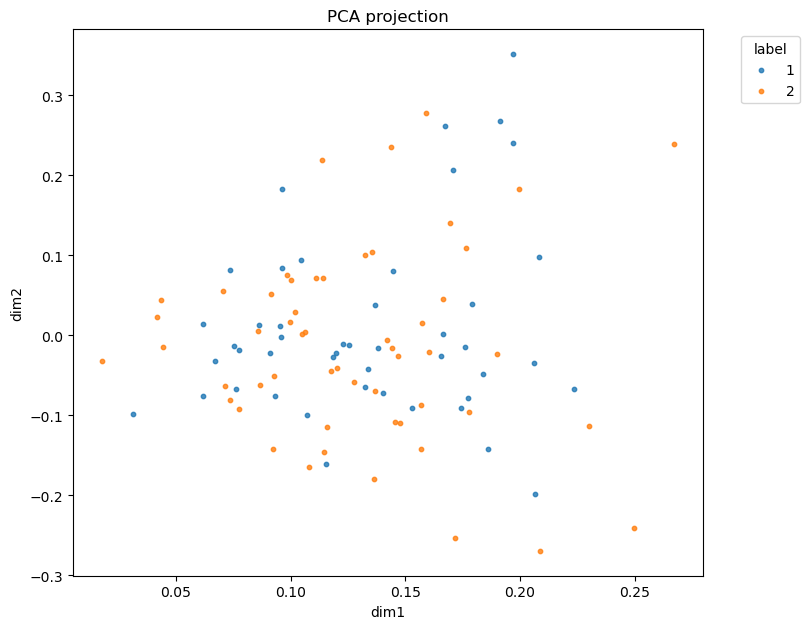

array([[ 0.24971869, -0.24035403],
       [ 0.09609129,  0.18224695],
       [ 0.09625431,  0.08365669],
       [ 0.07628224, -0.06764982],
       [ 0.15660496, -0.14191347],
       [ 0.15282186, -0.09097477],
       [ 0.19689961,  0.3510601 ],
       [ 0.11561145, -0.16017049],
       [ 0.04175182,  0.02230603],
       [ 0.17098085,  0.20698612],
       [ 0.13668762,  0.03816205],
       [ 0.11109742,  0.07164268],
       [ 0.14658422, -0.0255605 ],
       [ 0.1001144 ,  0.06934525],
       [ 0.09567612, -0.00163561],
       [ 0.09523621,  0.01112205],
       [ 0.26715341,  0.23886986],
       [ 0.14565687, -0.10835141],
       [ 0.01759885, -0.03267154],
       [ 0.18362594, -0.0486637 ],
       [ 0.11417716,  0.07193388],
       [ 0.14440843,  0.08053714],
       [ 0.09273703, -0.05058457],
       [ 0.19708594,  0.23982062],
       [ 0.11747759, -0.0440337 ],
       [ 0.14180237, -0.00634743],
       [ 0.04436779, -0.01489537],
       [ 0.12021725, -0.04141689],
       [ 0.20593988,

In [36]:
plot_dimensionality_reduction(tfidf_train, feat_eng_train['review_target'], method='PCA')


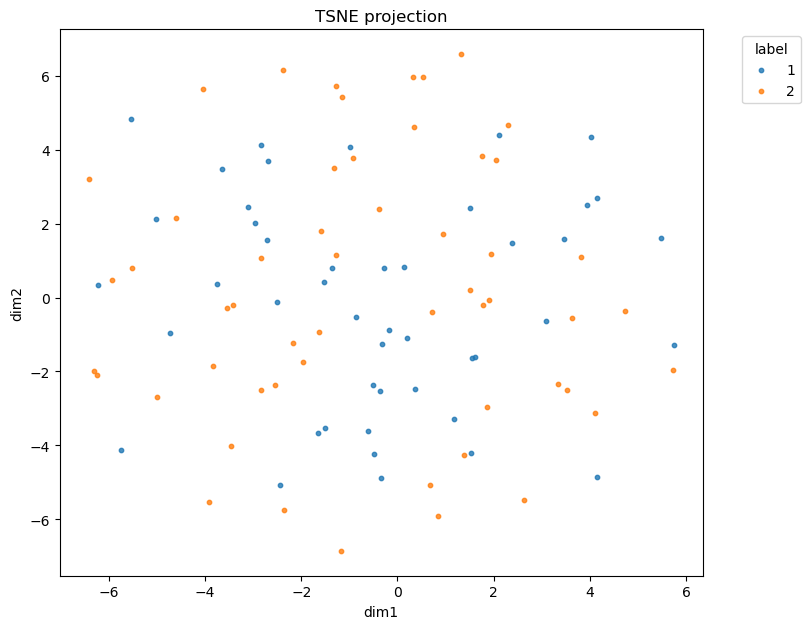

array([[ 1.5020615 ,  0.19405377],
       [-5.0242257 ,  2.1145763 ],
       [ 4.020647  ,  4.359212  ],
       [ 0.36465445, -2.4735527 ],
       [ 3.3356378 , -2.3364391 ],
       [ 1.5583607 , -1.6219741 ],
       [-2.7069633 ,  1.551204  ],
       [-0.61629647, -3.6128304 ],
       [-0.37801498,  2.4106193 ],
       [-0.99078107,  4.082479  ],
       [-0.50781167, -2.3759093 ],
       [-1.2872399 ,  5.714112  ],
       [ 2.2927701 ,  4.6773767 ],
       [ 0.84822756, -5.9174466 ],
       [ 1.5201223 , -4.2136207 ],
       [ 1.5132527 ,  2.4239852 ],
       [-1.2679023 ,  1.1645324 ],
       [-3.4537897 , -4.020585  ],
       [-2.3521361 , -5.7364383 ],
       [ 3.9316034 ,  2.5047534 ],
       [-3.8445036 , -1.8530055 ],
       [-6.222216  ,  0.34912193],
       [ 1.8569876 , -2.952657  ],
       [-2.511032  , -0.12483836],
       [ 4.7353683 , -0.3703264 ],
       [ 3.6385353 , -0.5401146 ],
       [-4.0540023 ,  5.646481  ],
       [ 0.32902318,  5.972672  ],
       [ 2.1053605 ,

In [37]:
plot_dimensionality_reduction(tfidf_train, feat_eng_train['review_target'], method='TSNE')


Save the tfidf and processed data

In [39]:
save(base_path='data/processed', df=feat_eng_train, df_name='feat_eng_train.csv', vectorizer=tfidf_train, vectorizer_name='tfidf_train.joblib')

Saved dataframe to data/processed/feat_eng_train.csv
Saved vectorizer to data/processed/tfidf_train.joblib


{'csv': PosixPath('data/processed/feat_eng_train.csv'),
 'vectorizer': PosixPath('data/processed/tfidf_train.joblib')}